# Practice

In [11]:

import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix,classification_report

data = {
    "age"           : [22,23,24,22,25,26,23,24,25,22,
                       23,24,25,26,22,23,24,25,26,22,
                       23,24,25,26,27,22,23,24,25,26],
    "cgpa"          : [8.5,7.2,9.1,6.5,8.8,9.5,7.8,8.2,9.0,6.8,
                       7.5,8.9,9.2,7.1,8.4,6.9,9.3,8.7,7.6,8.1,
                       9.4,7.3,8.6,9.1,7.9,8.3,6.7,9.0,8.5,7.4],
    "internships"   : [1,0,2,0,1,2,1,1,2,0,
                       1,2,2,0,1,0,2,1,1,1,
                       2,0,1,2,1,1,0,2,1,0],
    "projects"      : [2,1,3,1,2,4,2,2,3,1,
                       2,3,4,1,2,1,3,2,2,2,
                       4,1,2,3,2,2,1,3,2,1],
    "communication" : [7,6,9,5,8,9,7,8,9,6,
                       7,8,9,6,8,5,9,8,7,8,
                       9,6,8,9,7,8,6,9,8,6],
    "placed"        : [1,0,1,0,1,1,1,1,1,0,
                       1,1,1,0,1,0,1,1,1,1,
                       1,0,1,1,1,1,0,1,1,0]
    # 1 = placed, 0 = not placed
}
df= pd.DataFrame(data)

X=df[["age","cgpa","internships","projects","communication"]]
y=df["placed"]

X_train, X_test, y_train, y_test = train_test_split(  
   X, y, test_size=0.2, random_state=42)  


model=RandomForestClassifier(
            n_estimators=100,
            criterion="gini",
            bootstrap=True,
            max_depth=2,
            min_samples_split=2,
            min_samples_leaf=1,
            random_state=42,
            n_jobs=-1,
            max_features="sqrt"
)
model.fit(X_train,y_train)
y_pred= model.predict(X_test)


# Train acc
train_acc= accuracy_score(y_train,model.predict(X_train))
test_acc=accuracy_score(y_test,y_pred)

print("Train Accuracy:", train_acc)
print("Test Accuracy :", test_acc)
print("Difference    :", round(train_acc-test_acc, 2))
print("\nClassification Report:")
print(classification_report(y_test, y_pred))


Train Accuracy: 1.0
Test Accuracy : 1.0
Difference    : 0.0

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00         2
           1       1.00      1.00      1.00         4

    accuracy                           1.00         6
   macro avg       1.00      1.00      1.00         6
weighted avg       1.00      1.00      1.00         6



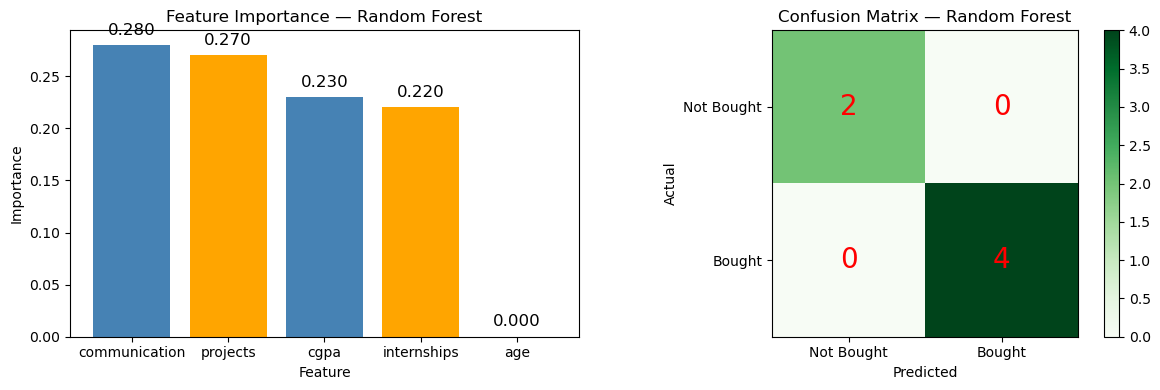

In [12]:
import matplotlib.pyplot as plt
plt.figure(figsize=(12, 4))

# Plot 1 — Feature Importance
plt.subplot(1, 2, 1)
importance = pd.DataFrame({
    "feature"   : ["age","cgpa","internships","projects","communication"],
    "importance": model.feature_importances_
}).sort_values("importance", ascending=False)

plt.bar(importance["feature"],
        importance["importance"],
        color=["steelblue", "orange"])
plt.title("Feature Importance — Random Forest")
plt.xlabel("Feature")
plt.ylabel("Importance")

# add values on bars
for i, v in enumerate(importance["importance"]):
    plt.text(i, v + 0.01, f"{v:.3f}",
             ha="center", fontsize=12)

# Plot 2 — Confusion Matrix
plt.subplot(1, 2, 2)
cm = confusion_matrix(y_test, y_pred)
plt.imshow(cm, cmap="Greens")
plt.colorbar()
plt.title("Confusion Matrix — Random Forest")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.xticks([0,1], ["Not Bought", "Bought"])
plt.yticks([0,1], ["Not Bought", "Bought"])
for i in range(2):
    for j in range(2):
        plt.text(j, i, cm[i,j],
                ha="center", va="center",
                color="red", fontsize=20)
plt.tight_layout()
plt.show()

In [18]:
new_stud = pd.DataFrame({
    "age"           : [24],
    "cgpa"          : [8.0],
    "internships"   : [1],
    "projects"      : [2],
    "communication" : [8],
    # 1 = placed, 0 = not placed
})

pred = model.predict(new_stud)
prob = model.predict_proba(new_stud)

print("Prediction  :", "Placed ✅" if pred[0]==1 else "Not Placed ❌")
print("Probability :", prob)


Prediction  : Placed ✅
Probability : [[0. 1.]]
